# Worksheet 6 -- Classical Machine Learning

In [1]:
import numpy as np
import pandas as pd

### Task 1 -- Data

In [2]:
df = pd.read_csv('planet_data.csv', on_bad_lines='skip', comment="#")
features_raw = ['pl_masse', 'pl_rade', 'pl_dens', 'pl_orbsmax', 'pl_orbper']
df_clean = df.dropna(subset=features_raw).copy()
df_clean = df_clean[(df_clean[features_raw] > 0).all(axis=1)].reset_index(drop=True)

In [3]:
X_all = np.column_stack([
    np.log10(df_clean['pl_masse']),   # log mass [Earth masses]
    np.log10(df_clean['pl_rade']),     # log radius [Earth radii]
    np.log10(df_clean['pl_dens']),     # log density [g/cm^3]
    np.log10(df_clean['pl_orbsmax']),  # log semi-major axis [AU]
    np.log10(df_clean['pl_orbper']),   # log orbital period [days]
])


print(f"Clean sample: {len(X_all)} exoplanets, {X_all.shape[1]} features")

Clean sample: 2115 exoplanets, 5 features


### Task 2 -- Creating Labels

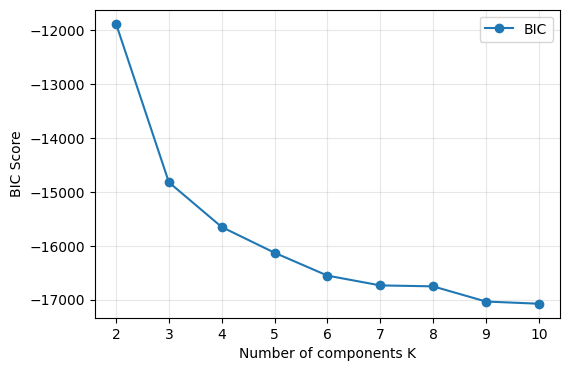

In [4]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Try K = 2 .. 10 and compute BIC/AIC.
# 'full' covariance lets each Gaussian have an arbitrary elongation and
# orientation -- important for power-law-shaped populations in log space.
ks = range(2, 11)
bics = []
for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=20)
    gmm.fit(X_all)
    bics.append(gmm.bic(X_all))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, bics, 'o-', label='BIC')
ax.set_xlabel('Number of components K')
ax.set_ylabel('BIC Score')
ax.legend(); ax.grid(alpha=0.3)

gmm = GaussianMixture(n_components=7, random_state=42, n_init=20)
gmm.fit(X_all)
labels = gmm.predict(X_all)
df_clean['gmm_label'] = labels

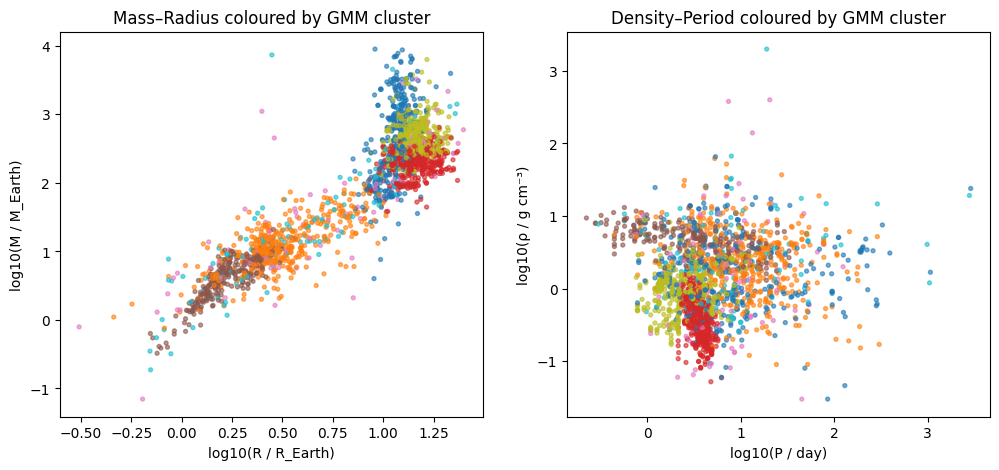

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_all[:, 1], X_all[:, 0], c=labels, s=8, cmap='tab10', alpha=0.6)
axes[0].set_xlabel('log10(R / R_Earth)'); axes[0].set_ylabel('log10(M / M_Earth)')
axes[0].set_title('Mass–Radius coloured by GMM cluster')

axes[1].scatter(X_all[:, 4], X_all[:, 2], c=labels, s=8, cmap='tab10', alpha=0.6)
axes[1].set_xlabel('log10(P / day)'); axes[1].set_ylabel('log10(ρ / g cm⁻³)')
axes[1].set_title('Density–Period coloured by GMM cluster')
plt.show()

In [6]:
import pandas as pd

centroids_log = gmm.means_                           # shape (K, D), in log10 units
centroids_phys = pd.DataFrame(
    10**centroids_log,
    columns=['mass [M_E]', 'radius [R_E]', 'density [g/cm³]', 'a [AU]', 'period [d]']
)
centroids_phys['n_members'] = [int(np.sum(labels == k)) for k in range(7)]
centroids_phys.index.name = 'cluster_id'
display(centroids_phys.round(2))

,mass [M_E],radius [R_E],density [g/cm³],a [AU],period [d],n_members
cluster_id,,,,,,
0,427.03,11.72,1.45,0.07,6.90,404
1,12.39,3.17,2.13,0.10,11.23,420
2,202.79,14.55,0.37,0.05,3.52,444
3,4.26,1.75,4.37,0.04,3.45,251
4,47.33,5.64,1.24,0.07,6.58,101
5,474.06,14.38,0.90,0.04,2.56,369
6,25.47,4.01,2.25,0.06,7.07,126


/tmp/ipykernel_289449/2347056975.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(loc='best', fontsize=8)


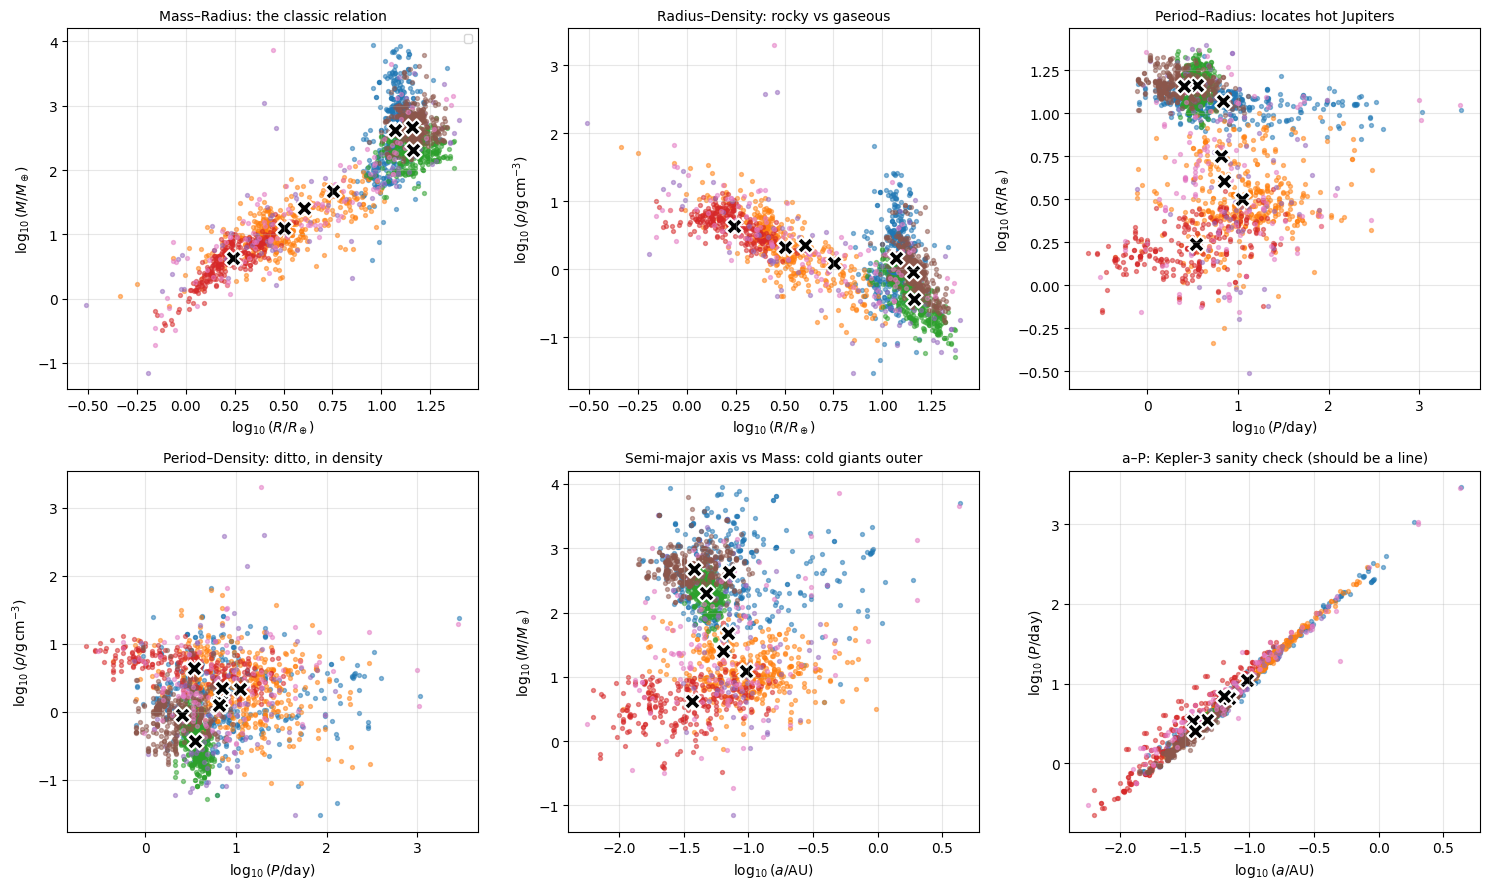

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

feature_labels = [
    r'$\log_{10}(M/M_\oplus)$',
    r'$\log_{10}(R/R_\oplus)$',
    r'$\log_{10}(\rho/\mathrm{g\,cm}^{-3})$',
    r'$\log_{10}(a/\mathrm{AU})$',
    r'$\log_{10}(P/\mathrm{day})$',
]

# (x_col, y_col, what-this-pair-shows)
pairs = [
    (1, 0, 'Mass–Radius: the classic relation'),
    (1, 2, 'Radius–Density: rocky vs gaseous'),
    (4, 1, 'Period–Radius: locates hot Jupiters'),
    (4, 2, 'Period–Density: ditto, in density'),
    (3, 0, 'Semi-major axis vs Mass: cold giants outer'),
    (3, 4, 'a–P: Kepler-3 sanity check (should be a line)'),
]

colors = cm.tab10(np.arange(7))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (xc, yc, title) in zip(axes.flat, pairs):
    for k in range(7):
        m = labels == k
        ax.scatter(X_all[m, xc], X_all[m, yc],
                   s=8, alpha=0.5, color=colors[k])
    # overlay the centroids
    ax.scatter(centroids_log[:, xc], centroids_log[:, yc],
               marker='X', s=140, c='black', edgecolor='white', linewidth=1.5)
    ax.set_xlabel(feature_labels[xc])
    ax.set_ylabel(feature_labels[yc])
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)

# One shared legend at the figure level
axes[0, 0].legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()